In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Prepare DF for further calculation
# Check understand_data.
df = pd.read_csv('../raw/marketing.csv')
df['date_served'] = pd.to_datetime(df['date_served'], format='%m/%d/%y')

In [4]:
# Comparing language conversion rate
# Group by language_displayed and count unique users
total = df.groupby(['language_displayed'])['user_id'].nunique()

# Group by language_displayed and count unique conversions
subscribers = df[df['converted'] == True].groupby(['language_displayed'])['user_id'].nunique()

# Calculate the conversion rate for all languages
language_conversion_rate = subscribers/total
print(language_conversion_rate)

language_displayed
Arabic     0.500000
English    0.129167
German     0.716216
Spanish    0.200000
Name: user_id, dtype: float64


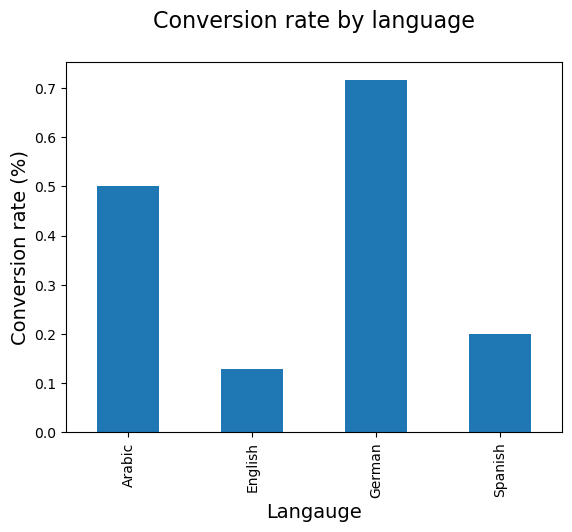

In [5]:
# Create a bar chart using channel retention DataFrame
language_conversion_rate.plot(kind = 'bar')

# Add a title and x and y-axis labels
plt.title('Conversion rate by language\n', size = 16)
plt.xlabel('Langauge', size = 14)
plt.ylabel('Conversion rate (%)', size = 14)

#Display the plot
plt.show()


In [7]:
# Group by date_served and count unique users
total = df.groupby(['date_served'])\
                                  ['user_id'].nunique()

# Group by date_served and count unique converted users
subscribers = df[df['converted'] == True]\
                       .groupby(['date_served'])\
                       ['user_id'].nunique()

# Calculate the conversion rate per day
daily_conversion_rate = subscribers/total
print(daily_conversion_rate)

date_served
2018-01-01    0.099448
2018-01-02    0.098930
2018-01-03    0.103448
2018-01-04    0.108359
2018-01-05    0.125392
2018-01-06    0.113636
2018-01-07    0.141818
2018-01-08    0.115385
2018-01-09    0.125000
2018-01-10    0.118694
2018-01-11    0.080645
2018-01-12    0.076412
2018-01-13    0.084967
2018-01-14    0.085246
2018-01-15    0.113429
2018-01-16    0.255155
2018-01-17    0.219512
2018-01-18    0.091195
2018-01-19    0.059016
2018-01-20    0.067524
2018-01-21    0.087336
2018-01-22    0.123596
2018-01-23    0.122093
2018-01-24    0.115789
2018-01-25    0.125000
2018-01-26    0.090090
2018-01-27    0.065625
2018-01-28    0.062500
2018-01-29    0.059561
2018-01-30    0.066246
2018-01-31    0.052941
Name: user_id, dtype: float64


In [8]:
#Reset index to turn the Series into a DF
daily_conversion_rate = pd.DataFrame(daily_conversion_rate.reset_index())

#Rename columns
daily_conversion_rate.columns = ['date_subscribed', 'conversion_rate']


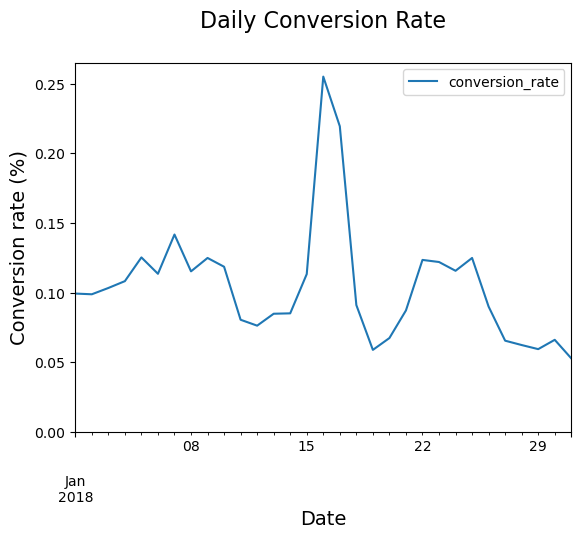

In [9]:
# Create a line chart using the daily_conversion_rate DF 
daily_conversion_rate.plot('date_subscribed', 'conversion_rate')

# Add a title and x and y-axis labels
plt.title('Daily Conversion Rate\n', size = 16)
plt.xlabel('Date', size = 14)
plt.ylabel('Conversion rate (%)', size = 14)

# Set the y-axis to begin at 0
plt.ylim(0)

#Display the plot
plt.show()

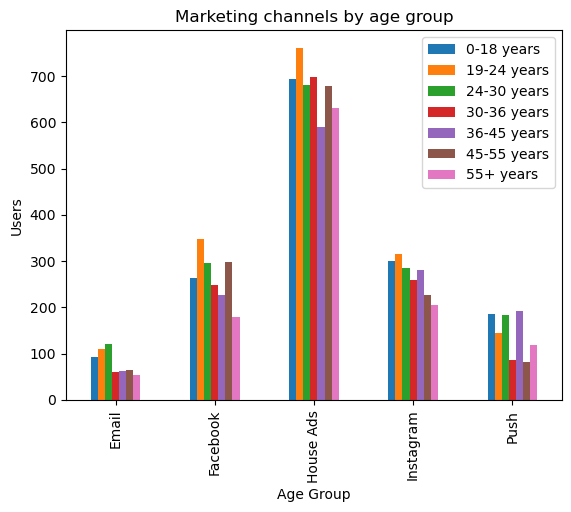

In [11]:
channel_age = df.groupby(['marketing_channel', 'age_group'])\
                                ['user_id'].count()

# Unstack channel_age and transform it into a DataFrame
channel_age_df = pd.DataFrame(channel_age.unstack(level = 1))

# Plot channel_age
channel_age_df.plot(kind = 'bar')
plt.title('Marketing channels by age group')
plt.xlabel('Age Group')
plt.ylabel('Users')
# Add a legend to the plot
plt.legend(loc = 'upper right', 
           labels = channel_age_df.columns.values)
plt.show()

date_subscribed  subscribing_channel
1/1/18           Email                   1
                 Facebook                8
                 House Ads              16
                 Instagram               8
                 Push                    3
Name: user_id, dtype: int64
date_subscribed  subscribing_channel
1/1/18           Email                   1
                 Facebook                7
                 House Ads              11
                 Instagram               6
                 Push                    3
Name: user_id, dtype: int64


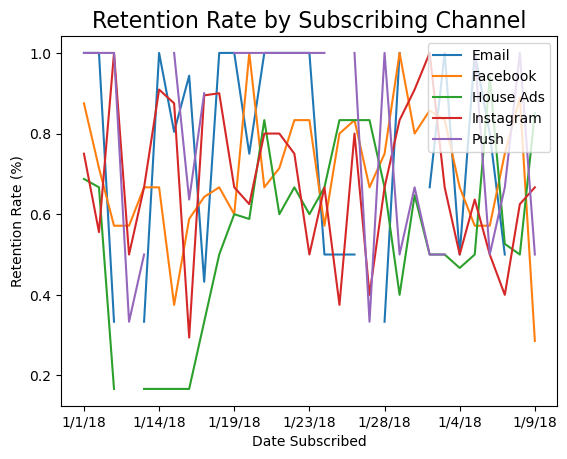

In [16]:
# Count the subs by subscribing channel and day
retention_total = df.groupby(['date_subscribed',
                                     'subscribing_channel'])['user_id'].nunique()

# Print results
print(retention_total.head())



# Sum the retained subs by subscribing channel and date subscribed
retention_subs = df[df['is_retained'] == True].groupby(['date_subscribed', 
                                       'subscribing_channel'])['user_id'].nunique()

# Print results
print(retention_subs.head())



# Divide retained subscribers by total subscribers
retention_rate = retention_subs/retention_total
retention_rate_df = pd.DataFrame(retention_rate.unstack(level=1))

# Plot retention rate
retention_rate_df.plot()

# Add a title, x-label, y-label, legend and display the plot
plt.title('Retention Rate by Subscribing Channel', size = 16)
plt.xlabel('Date Subscribed')
plt.ylabel('Retention Rate (%)')
plt.legend(loc = 'upper right', labels = retention_rate_df.columns.values)
plt.show()